In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
df = pd.read_csv("../data/raw/train.csv")

# Exploratory Data Analysis (EDA)

In [3]:
df.shape

(45593, 20)

In [4]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [6]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [7]:
df.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [8]:
df["Time_taken(min)"].head()


0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: str

In [9]:
df["Time_taken(min)"] = df["Time_taken(min)"].str.extract(r'(\d+)').astype(int)

In [10]:
df["Time_taken(min)"].dtype

dtype('int64')

In [11]:
df["Time_taken(min)"].head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64

In [12]:
df["Delivery_person_Age"].unique()[:10]

<StringArray>
['37', '34', '23', '38', '32', '22', '33', '35', '36', '21']
Length: 10, dtype: str

In [13]:
df["Delivery_person_Ratings"].unique()[:10]

<StringArray>
['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1']
Length: 10, dtype: str

In [14]:
df["multiple_deliveries"].unique()

<StringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str

# Data Cleaning

In [15]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
#filling NULL values
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].median()
)

In [17]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [18]:
print(df["Time_Orderd"].head(20).tolist())

['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00', '21:20:00', '19:15:00', '17:25:00', '20:55:00', '21:55:00', '14:55:00', '17:30:00', '09:20:00', '19:50:00', '20:25:00', '14:55:00', '20:30:00', '20:40:00', '21:15:00', '20:20:00']


In [19]:
print(df["Time_Order_picked"].head(20).tolist())

['11:45:00', '19:50:00', '08:45:00', '18:10:00', '13:45:00', '21:30:00', '19:30:00', '17:30:00', '21:05:00', '22:10:00', '15:05:00', '17:40:00', '09:30:00', '20:05:00', '20:35:00', '15:10:00', '20:40:00', '20:50:00', '21:30:00', '20:25:00']


In [20]:
if df["Time_taken(min)"].dtype == "object":
    
    df["Time_taken(min)"] = (
        df["Time_taken(min)"]
        .str.extract(r'(\d+)')
        .astype(int)
    )

In [21]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].median()
)

# Time-Based Feature Engineering

In [22]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format='%H:%M:%S',
    errors='coerce'
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format='%H:%M:%S',
    errors='coerce'
)

In [23]:
df[[
    "Time_Orderd",
    "Time_Order_picked"
]].head()

,Time_Orderd,Time_Order_picked
0,1900-01-01 11:30:00,1900-01-01 11:45:00
1,1900-01-01 19:45:00,1900-01-01 19:50:00
2,1900-01-01 08:30:00,1900-01-01 08:45:00
3,1900-01-01 18:00:00,1900-01-01 18:10:00
4,1900-01-01 13:30:00,1900-01-01 13:45:00


In [24]:
df[[
    "Time_Orderd",
    "Time_Order_picked"
]].dtypes

Time_Orderd          datetime64[us]
Time_Order_picked    datetime64[us]
dtype: object

In [25]:
df["order_hour"] = df["Time_Orderd"].dt.hour

In [26]:
df[["Time_Orderd", "order_hour"]].head()

,Time_Orderd,order_hour
0,1900-01-01 11:30:00,11.0
1,1900-01-01 19:45:00,19.0
2,1900-01-01 08:30:00,8.0
3,1900-01-01 18:00:00,18.0
4,1900-01-01 13:30:00,13.0


In [27]:
df["pickup_time_minutes"] = (
    (
        df["Time_Order_picked"] -
        df["Time_Orderd"]
    ).dt.total_seconds()
) / 60

In [28]:
df[[
    "pickup_time_minutes"
]].head()

,pickup_time_minutes
0,15.0
1,5.0
2,15.0
3,10.0
4,15.0


In [29]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'order_hour', 'pickup_time_minutes'],
      dtype='str')

In [30]:
df[["pickup_time_minutes"]].head()

,pickup_time_minutes
0,15.0
1,5.0
2,15.0
3,10.0
4,15.0


In [31]:
df["pickup_time_minutes"] = (
    df["pickup_time_minutes"].abs()
)

In [32]:
df[[
    "Time_Orderd",
    "Time_Order_picked",
    "pickup_time_minutes"
]].head()

,Time_Orderd,Time_Order_picked,pickup_time_minutes
0,1900-01-01 11:30:00,1900-01-01 11:45:00,15.0
1,1900-01-01 19:45:00,1900-01-01 19:50:00,5.0
2,1900-01-01 08:30:00,1900-01-01 08:45:00,15.0
3,1900-01-01 18:00:00,1900-01-01 18:10:00,10.0
4,1900-01-01 13:30:00,1900-01-01 13:45:00,15.0


In [33]:
df["order_hour"] = df["Time_Orderd"].dt.hour

In [34]:
df[[
    "Time_Orderd",
    "order_hour"
]].head()

,Time_Orderd,order_hour
0,1900-01-01 11:30:00,11.0
1,1900-01-01 19:45:00,19.0
2,1900-01-01 08:30:00,8.0
3,1900-01-01 18:00:00,18.0
4,1900-01-01 13:30:00,13.0


# Distance Feature Engineering

In [35]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    
    lon1, lat1, lon2, lat2 = map(
        radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * asin(sqrt(a))

    r = 6371

    return c * r

In [36]:
#creating distance coloumn
df["distance_km"] = df.apply(
    lambda row: haversine(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

In [37]:
df[["distance_km"]].head()

,distance_km
0,3.025149
1,20.183530
2,1.552758
3,7.790401
4,6.210138


# Outlier Detection and Handling

In [38]:
df["distance_km"].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64

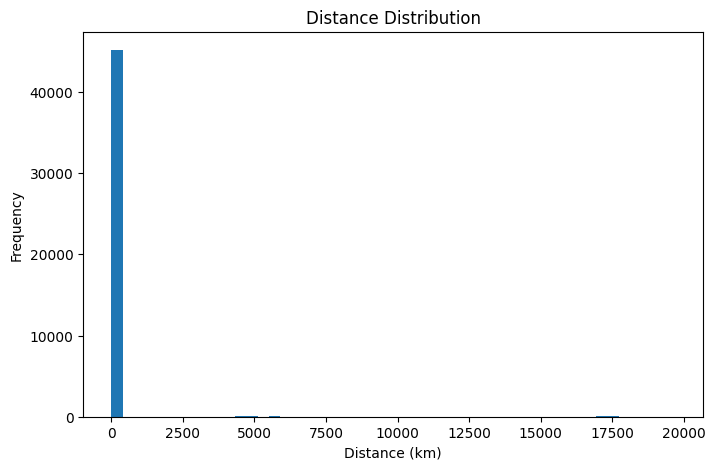

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["distance_km"], bins=50)

plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.title("Distance Distribution")

plt.show()

Hnadling outliers for Distance

In [40]:
# Handling outliers
df = df[df["distance_km"] < 50]

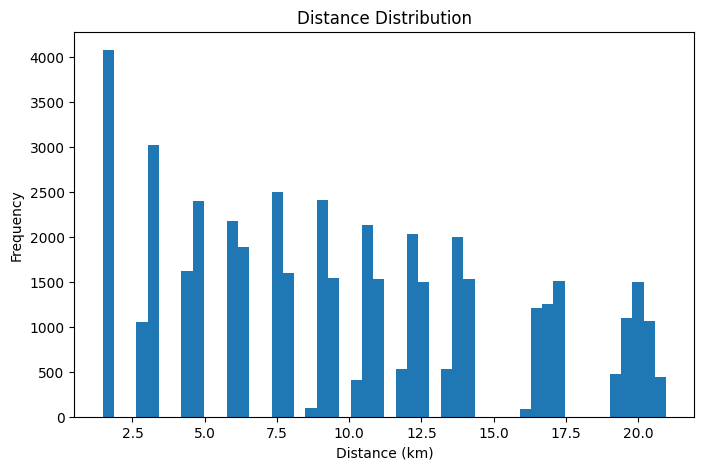

In [41]:
plt.figure(figsize=(8,5))

plt.hist(df["distance_km"], bins=50)

plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.title("Distance Distribution")

plt.show()

In [42]:
df["Time_taken(min)"].describe()

count    45162.000000
mean        26.298038
std          9.383733
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

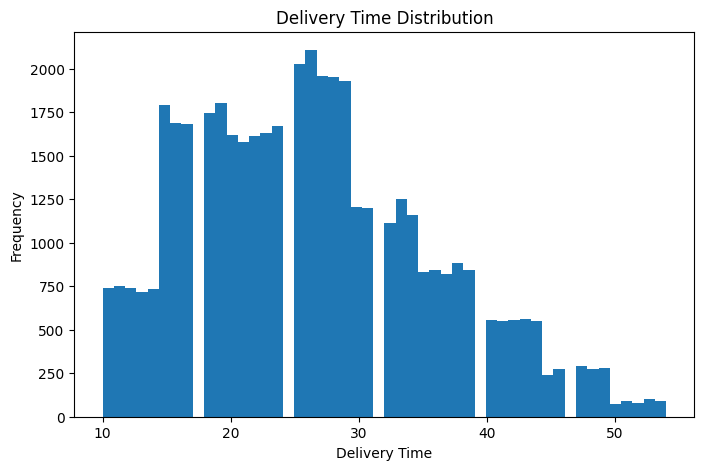

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df["Time_taken(min)"], bins=50)

plt.xlabel("Delivery Time")
plt.ylabel("Frequency")
plt.title("Delivery Time Distribution")

plt.show()

In [44]:
df["pickup_time_minutes"].describe()

count    43706.000000
mean        36.857411
std        193.514185
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max       1435.000000
Name: pickup_time_minutes, dtype: float64

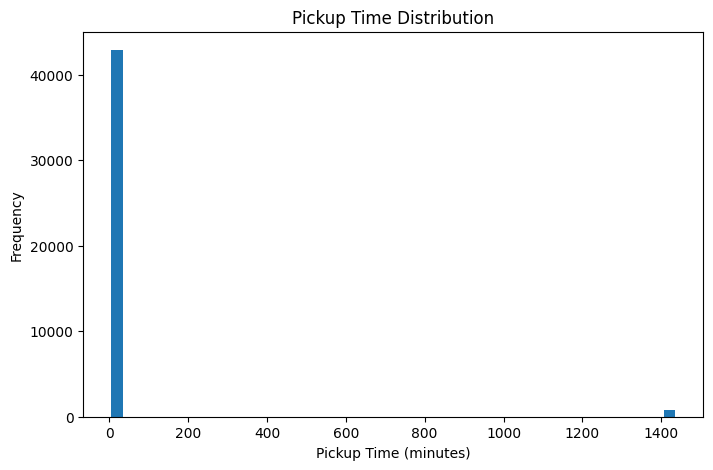

In [45]:
plt.figure(figsize=(8,5))

plt.hist(df["pickup_time_minutes"], bins=50)

plt.xlabel("Pickup Time (minutes)")
plt.ylabel("Frequency")
plt.title("Pickup Time Distribution")

plt.show()

In [46]:
df = df[df["pickup_time_minutes"] < 60]

In [47]:
df["pickup_time_minutes"].describe()

count    42877.000000
mean         9.955920
std          4.086528
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_time_minutes, dtype: float64

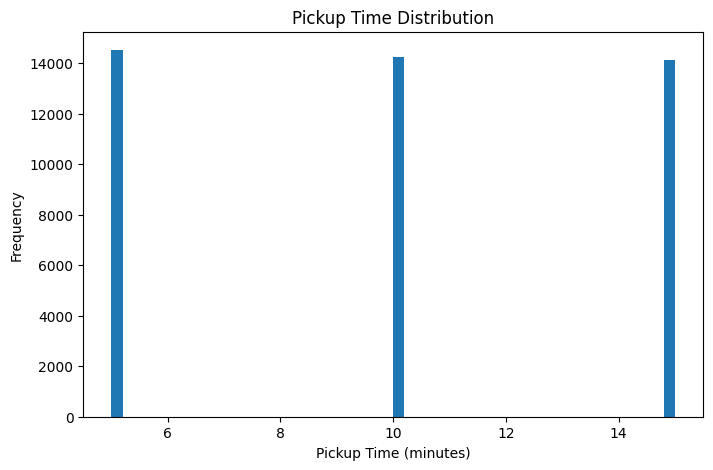

In [48]:
plt.figure(figsize=(8,5))

plt.hist(df["pickup_time_minutes"], bins=50)

plt.xlabel("Pickup Time (minutes)")
plt.ylabel("Frequency")
plt.title("Pickup Time Distribution")

plt.show()

In [49]:
df.select_dtypes(include='object').columns

C:\Users\hemas\AppData\Local\Temp\ipykernel_34496\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['ID', 'Delivery_person_ID', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival',
       'City'],
      dtype='str')

In [50]:
#dropping the columns which do not help for prediction
df = df.drop(
    ["ID", "Delivery_person_ID"],
    axis=1
)

# Categorical Encoding

In [51]:
from sklearn.preprocessing import LabelEncoder

In [52]:
label_encoder = LabelEncoder()

In [53]:
categorical_cols = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

In [54]:
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [55]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour,pickup_time_minutes,distance_km
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,1900-01-01 11:30:00,1900-01-01 11:45:00,4,...,2,3,1,0.0,1,3,24,11.0,15.0,3.025149
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,1900-01-01 19:45:00,1900-01-01 19:50:00,3,...,2,3,2,1.0,1,0,33,19.0,5.0,20.183530
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,1900-01-01 08:30:00,1900-01-01 08:45:00,2,...,0,1,1,1.0,1,3,26,8.0,15.0,1.552758
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,1900-01-01 18:00:00,1900-01-01 18:10:00,4,...,0,0,1,1.0,1,0,21,18.0,10.0,7.790401
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,1900-01-01 13:30:00,1900-01-01 13:45:00,0,...,1,3,2,1.0,1,0,30,13.0,15.0,6.210138


# Saving Processed Dataset

In [56]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

# Model Building

In [57]:
df = pd.read_csv("../data/processed/cleaned_data.csv")



In [58]:

df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'order_hour', 'pickup_time_minutes', 'distance_km'],
      dtype='str')

# Creating Features and Target

In [59]:
# Target variable
y = df["Time_taken(min)"]

# Features
X = df.drop(
    columns=[
        "Time_taken(min)",
        "Order_Date",
        "Time_Orderd",
        "Time_Order_picked",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
)


In [60]:
print(X.shape)
print(y.shape)

print(X.columns)

(42877, 13)
(42877,)
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'order_hour', 'pickup_time_minutes', 'distance_km'],
      dtype='str')


In [61]:
X.head()

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,order_hour,pickup_time_minutes,distance_km
0,37.0,4.9,4,0,2,3,1,0.0,1,3,11.0,15.0,3.025149
1,34.0,4.5,3,1,2,3,2,1.0,1,0,19.0,5.0,20.183530
2,23.0,4.4,2,2,0,1,1,1.0,1,3,8.0,15.0,1.552758
3,38.0,4.7,4,3,0,0,1,1.0,1,0,18.0,10.0,7.790401
4,32.0,4.6,0,0,1,3,2,1.0,1,0,13.0,15.0,6.210138


# Train-Test Split

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
print(X_train.shape)

(34301, 13)


In [64]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(34301, 13)
(8576, 13)
(34301,)
(8576,)


# Linear Regression

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
lr = LinearRegression()

In [67]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
y_pred = lr.predict(X_test)

In [69]:
print(y_pred[:5])

[24.73391428 27.73911114 30.05896171 18.79823813 29.17938265]


In [70]:
print(y_test.head())

22937    27
29039    36
3214     21
21597    18
41888    25
Name: Time_taken(min), dtype: int64


In [71]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred.round(2)
})

comparison["Error"] = (
    comparison["Actual"] - comparison["Predicted"]
).abs()

comparison.head(20)

,Actual,Predicted,Error
22937,27,24.73,2.27
29039,36,27.74,8.26
3214,21,30.06,9.06
21597,18,18.80,0.80
41888,25,29.18,4.18
36624,14,16.39,2.39
42244,38,33.52,4.48
23219,16,19.65,3.65
8442,19,21.28,2.28
12248,27,24.31,2.69


In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 5.385444459212113
MSE: 44.53704183074815
R2: 0.5052233409603405


In [73]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_test, y_pred, model_name):
    
    plt.figure(figsize=(8,6))
    
    plt.scatter(y_test, y_pred, alpha=0.5)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        linewidth=2
    )

    plt.xlabel("Actual Delivery Time")
    plt.ylabel("Predicted Delivery Time")
    plt.title(f"Actual vs Predicted ({model_name})")
    
    plt.show()

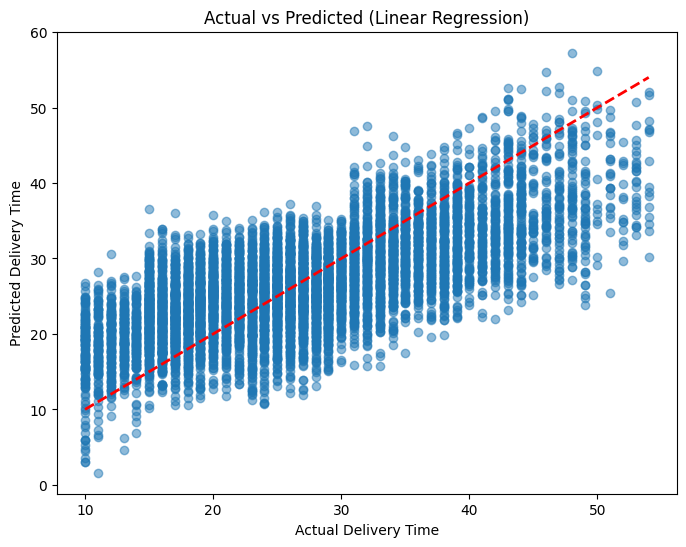

In [74]:
plot_actual_vs_predicted(
    y_test,
    y_pred,
    "Linear Regression"
)

# Feature Scaling

Certain machine learning algorithms are sensitive to the scale of input features. Features in the dataset have different ranges, such as delivery distance, delivery partner ratings, and age.

To ensure fair treatment of all features and improve model performance, StandardScaler was applied. StandardScaler transforms features so that they have a mean of 0 and a standard deviation of 1.

Feature scaling was used for:
- Ridge Regression
- Lasso Regression

Tree-based models such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost do not require feature scaling because they split data based on feature thresholds rather than distances.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression

In [76]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [77]:
comparison_ridge = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_ridge.round(2)
})

comparison_ridge["Error"] = (
    comparison_ridge["Actual"] -
    comparison_ridge["Predicted"]
).abs()

comparison_ridge.head(20)

,Actual,Predicted,Error
22937,27,24.73,2.27
29039,36,27.74,8.26
3214,21,30.06,9.06
21597,18,18.80,0.80
41888,25,29.18,4.18
36624,14,16.39,2.39
42244,38,33.52,4.48
23219,16,19.65,3.65
8442,19,21.28,2.28
12248,27,24.31,2.69


In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("R2:", r2_ridge)

MAE: 5.385448395813996
MSE: 44.53706832762654
R2: 0.5052230465977958


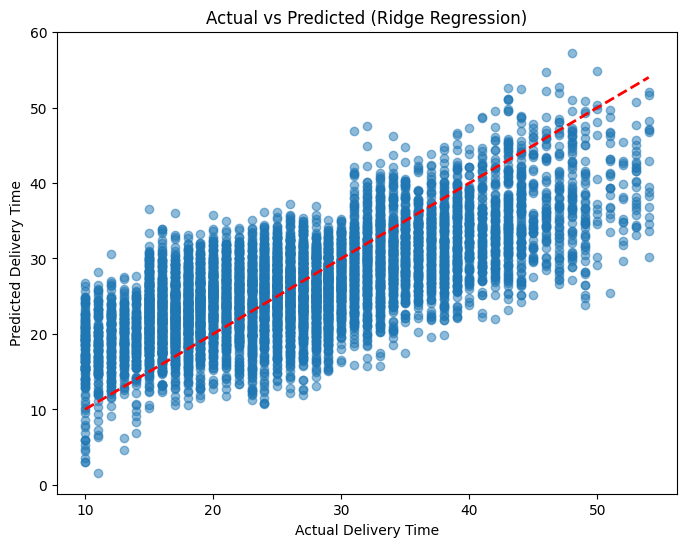

In [79]:
plot_actual_vs_predicted(
    y_test,
    y_pred_ridge,
    "Ridge Regression"
)

# Lasso Regression

In [80]:
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [81]:
comparison_lasso = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lasso.round(2)
})

comparison_lasso["Error"] = (
    comparison_lasso["Actual"] -
    comparison_lasso["Predicted"]
).abs()

comparison_lasso.head(20)

,Actual,Predicted,Error
22937,27,24.78,2.22
29039,36,29.26,6.74
3214,21,29.51,8.51
21597,18,22.43,4.43
41888,25,29.25,4.25
36624,14,19.45,5.45
42244,38,30.36,7.64
23219,16,22.44,6.44
8442,19,24.23,5.23
12248,27,25.61,1.39


In [82]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("R2:", r2_lasso)

MAE: 5.8446375554095695
MSE: 51.91012967064768
R2: 0.4233132809681467


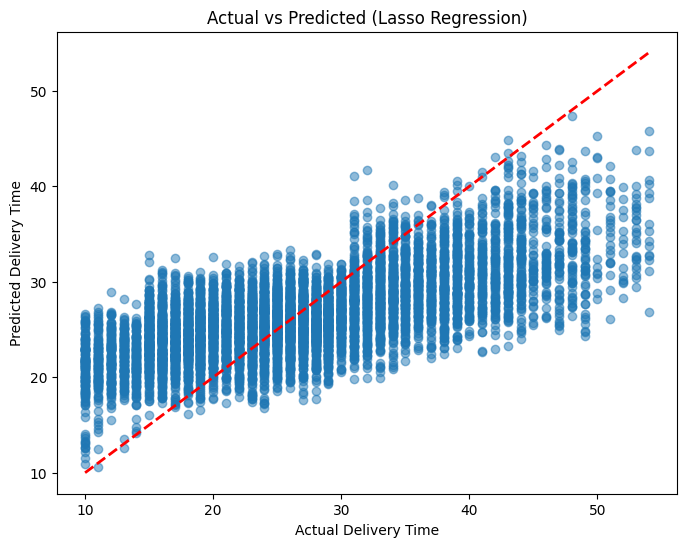

In [83]:
plot_actual_vs_predicted(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)

# Decision Tree Regression

In [84]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [85]:
comparison_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt.round(2)
})

comparison_dt["Error"] = (
    comparison_dt["Actual"] -
    comparison_dt["Predicted"]
).abs()

comparison_dt.head(20)

,Actual,Predicted,Error
22937,27,26.0,1.0
29039,36,33.0,3.0
3214,21,29.0,8.0
21597,18,18.0,0.0
41888,25,17.0,8.0
36624,14,10.0,4.0
42244,38,38.0,0.0
23219,16,10.0,6.0
8442,19,10.0,9.0
12248,27,28.0,1.0


In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("R2:", r2_dt)

MAE: 4.0591184701492535
MSE: 28.07101212686567
R2: 0.6881498854644731


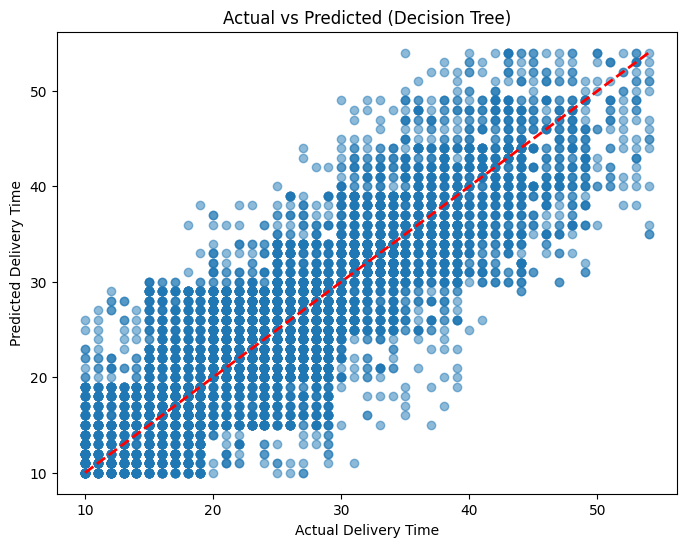

In [87]:
plot_actual_vs_predicted(
    y_test,
    y_pred_dt,
    "Decision Tree"
)

In [88]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

dt_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
1,Delivery_person_Ratings,0.217727
2,Weatherconditions,0.186019
12,distance_km,0.124590
7,multiple_deliveries,0.115511
3,Road_traffic_density,0.096155
0,Delivery_person_Age,0.089385
4,Vehicle_condition,0.069031
10,order_hour,0.057205
5,Type_of_order,0.014535
11,pickup_time_minutes,0.010441


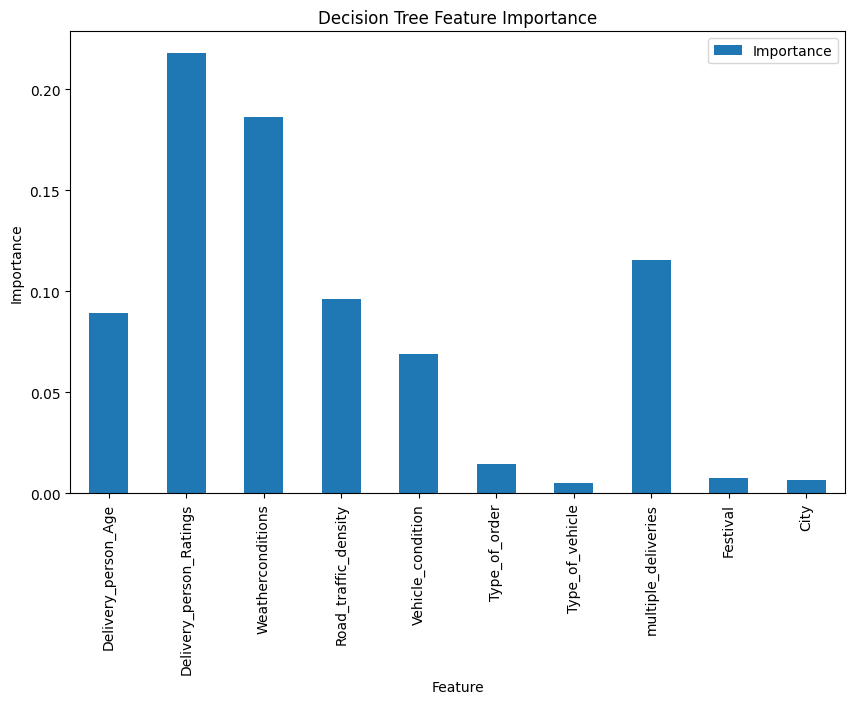

In [89]:
import matplotlib.pyplot as plt

dt_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)

plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")
plt.show()

# Random Forest Regression

In [90]:
from sklearn.ensemble import RandomForestRegressor

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [92]:
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf.round(2)
})

comparison_rf["Error"] = (
    comparison_rf["Actual"] - comparison_rf["Predicted"]
).abs()

comparison_rf.head(20)

,Actual,Predicted,Error
22937,27,29.81,2.81
29039,36,33.84,2.16
3214,21,22.49,1.49
21597,18,20.34,2.34
41888,25,23.49,1.51
36624,14,15.41,1.41
42244,38,44.30,6.30
23219,16,17.21,1.21
8442,19,14.63,4.37
12248,27,25.03,1.97


In [93]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2:", r2_rf)

MAE: 3.0721256996268655
MSE: 14.753730305503733
R2: 0.836095953191719


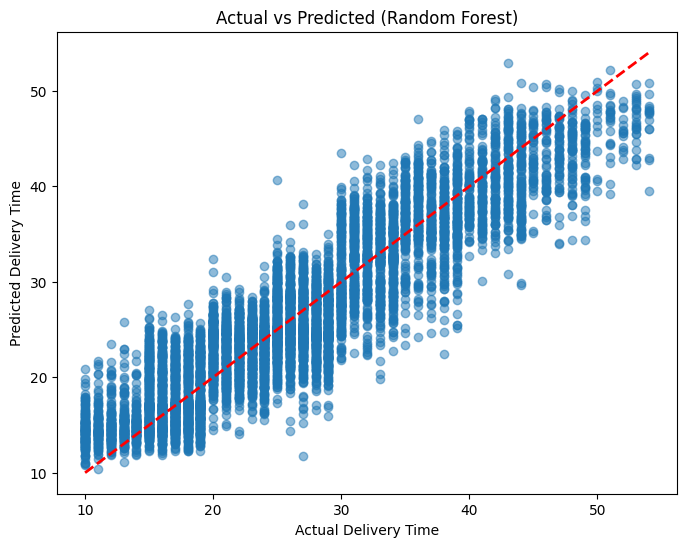

In [94]:
plot_actual_vs_predicted(
    y_test,
    y_pred_rf,
    "Random Forest"
)

In [95]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
1,Delivery_person_Ratings,0.218199
2,Weatherconditions,0.174281
12,distance_km,0.125668
7,multiple_deliveries,0.118887
0,Delivery_person_Age,0.089365
3,Road_traffic_density,0.088584
10,order_hour,0.070664
4,Vehicle_condition,0.067980
5,Type_of_order,0.013633
11,pickup_time_minutes,0.010565


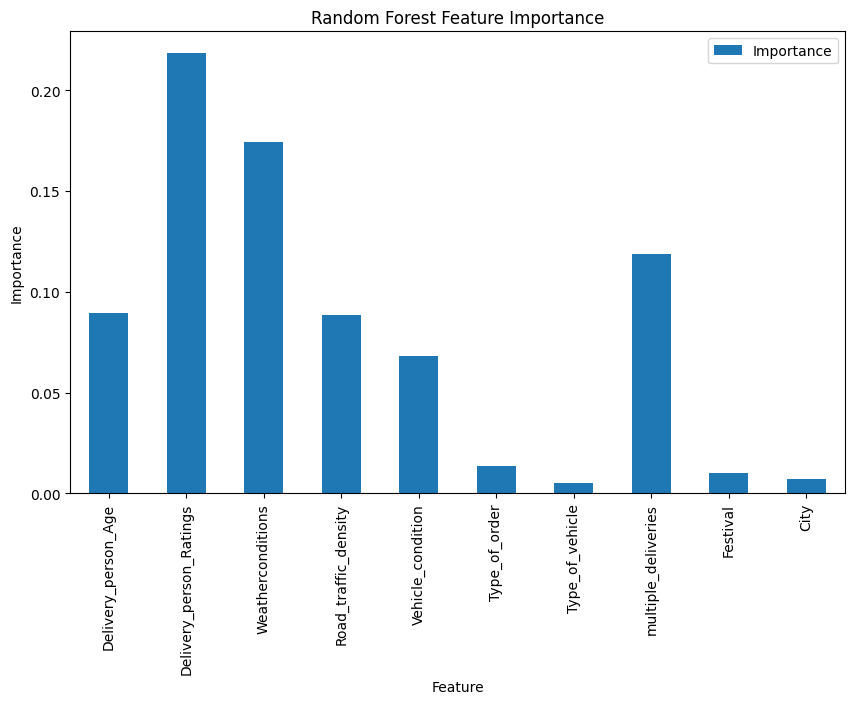

In [96]:
rf_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

# Gradient Boosting Regression

In [97]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

In [98]:
comparison_gbr = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_gbr.round(2)
})

comparison_gbr["Error"] = (
    comparison_gbr["Actual"] -
    comparison_gbr["Predicted"]
).abs()

comparison_gbr.head(20)

,Actual,Predicted,Error
22937,27,28.72,1.72
29039,36,34.29,1.71
3214,21,22.58,1.58
21597,18,23.63,5.63
41888,25,24.39,0.61
36624,14,17.54,3.54
42244,38,37.97,0.03
23219,16,21.64,5.64
8442,19,17.69,1.31
12248,27,21.27,5.73


In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE:", mae_gbr)
print("MSE:", mse_gbr)
print("R2:", r2_gbr)

MAE: 3.433699030278901
MSE: 18.377499433035698
R2: 0.7958383090296975


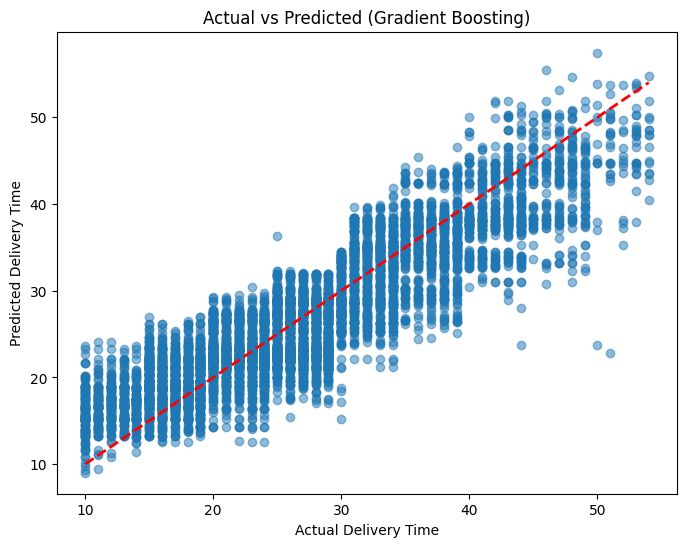

In [100]:
plot_actual_vs_predicted(
    y_test,
    y_pred_gbr,
    "Gradient Boosting"
)

In [101]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [102]:
import xgboost
print(xgboost.__version__)

3.3.0


In [103]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [104]:
y_pred_xgb = xgb.predict(X_test)

In [105]:
comparison_xgb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb.round(2)
})

comparison_xgb["Error"] = (
    comparison_xgb["Actual"] -
    comparison_xgb["Predicted"]
).abs()

comparison_xgb.head(20)

,Actual,Predicted,Error
22937,27,29.040001,2.040001
29039,36,35.049999,0.950001
3214,21,21.830000,0.830000
21597,18,21.000000,3.000000
41888,25,21.920000,3.080000
36624,14,15.600000,1.600000
42244,38,40.119999,2.119999
23219,16,19.650000,3.650000
8442,19,17.120001,1.879999
12248,27,23.940001,3.059999


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("R2:", r2_xgb)

MAE: 3.0400779247283936
MSE: 14.410140991210938
R2: 0.839913010597229


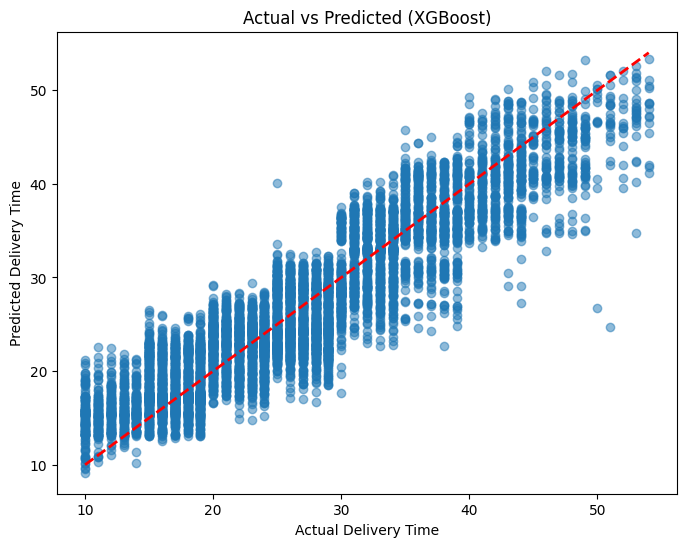

In [107]:
plot_actual_vs_predicted(
    y_test,
    y_pred_xgb,
    "XGBoost"
)

In [108]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
7,multiple_deliveries,0.189869
1,Delivery_person_Ratings,0.176577
3,Road_traffic_density,0.142358
2,Weatherconditions,0.128709
4,Vehicle_condition,0.090614
10,order_hour,0.083081
8,Festival,0.064095
0,Delivery_person_Age,0.055641
12,distance_km,0.042630
9,City,0.021371


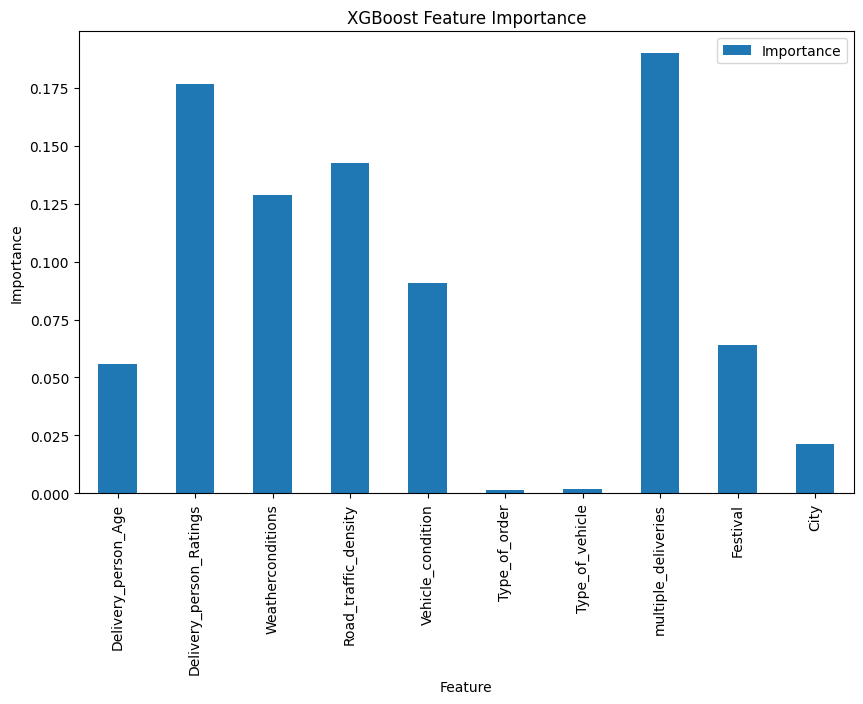

In [109]:
xgb_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)

plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.show()

In [110]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_ridge,
        mae_lasso,
        mae_dt,
        mae_rf,
        mae_gbr,
        mae_xgb
    ],
    "MSE": [
        mse,
        mse_ridge,
        mse_lasso,
        mse_dt,
        mse_rf,
        mse_gbr,
        mse_xgb
    ],
    "R2": [
        r2,
        r2_ridge,
        r2_lasso,
        r2_dt,
        r2_rf,
        r2_gbr,
        r2_xgb
    ]
})

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df

,Model,MAE,MSE,R2
6,XGBoost,3.040078,14.410141,0.839913
4,Random Forest,3.072126,14.753730,0.836096
5,Gradient Boosting,3.433699,18.377499,0.795838
3,Decision Tree,4.059118,28.071012,0.688150
0,Linear Regression,5.385444,44.537042,0.505223
1,Ridge,5.385448,44.537068,0.505223
2,Lasso,5.844638,51.910130,0.423313


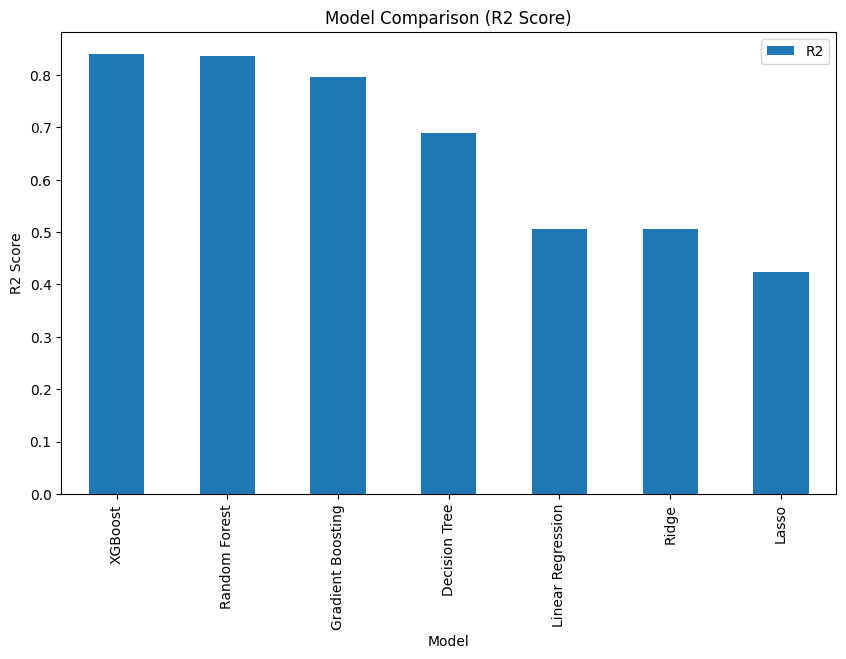

In [111]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

In [112]:
df[["distance_km", "Time_taken(min)"]].corr()

,distance_km,Time_taken(min)
distance_km,1.000000,0.326975
Time_taken(min),0.326975,1.000000


# Key Findings

- XGBoost achieved the best performance.
- MAE reduced from 5.39 minutes (Linear Regression) to 3.04 minutes.
- Tree-based ensemble methods significantly outperformed linear models.
- Multiple deliveries, delivery partner ratings, road traffic density, and weather conditions were the most important predictors.
- Distance showed only a moderate correlation (0.327) with delivery time.

# Conclusion

A food delivery time prediction system was developed using multiple machine learning algorithms.

Seven regression models were evaluated:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- XGBoost Regression

XGBoost achieved the best performance with:

- MAE: 3.04 minutes
- MSE: 14.41
- R² Score: 0.84

The results indicate that delivery time depends more on operational factors such as traffic, weather, ratings, and multiple deliveries than on distance alone.

XGBoost was selected as the final model.

In [113]:
import joblib

joblib.dump(xgb, "../models/xgboost_model.pkl")
joblib.dump(list(X.columns), "../models/features.pkl")

['../models/features.pkl']